# Reproducing Figure 6(a): SOGlasso vs Lasso, Glasso, OGlasso

This notebook reproduces the qualitative result of **Section 5.2** ("Toy
Data, Linear Regression") and **Figure 6(a)** of Rao, Nowak, Cox & Rogers
(2014), arXiv:1402.4512.

**Paper's setup:** overlapping groups of size B=6 (sliding by 4), M=100
groups, k=10 active groups, within-group sparsity fraction alpha varied
from 0 to 1, n=100 Gaussian measurements, noise sigma=0.1, averaged over
100 trials.

**This reproduction:** the same single-task construction (see
`soglasso.data.make_sog_regression`), with a reduced group count / trial
count for tractable notebook runtime, and per-method hyperparameters chosen
via a validation-set grid search (in place of the paper's oracle/clairvoyant
tuning).

**Expected qualitative result (paper's claim):** SOGlasso achieves the
lowest (or near-lowest) held-out MSE across the *entire* range of alpha,
because it is the only method that accounts for sparsity *both* across
groups *and* within groups.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
from tutorials.reproduce_figure6a import run_experiment, save_and_plot, ALPHAS

results = run_experiment()

trial 1/10 done


trial 2/10 done


trial 3/10 done


trial 4/10 done


trial 5/10 done


trial 6/10 done


trial 7/10 done


trial 8/10 done


trial 9/10 done


trial 10/10 done


Saved results table to /home/claude/soglasso/tutorials/figure6a_results.csv


Saved figure to /home/claude/soglasso/tutorials/figure6a_reproduction.png


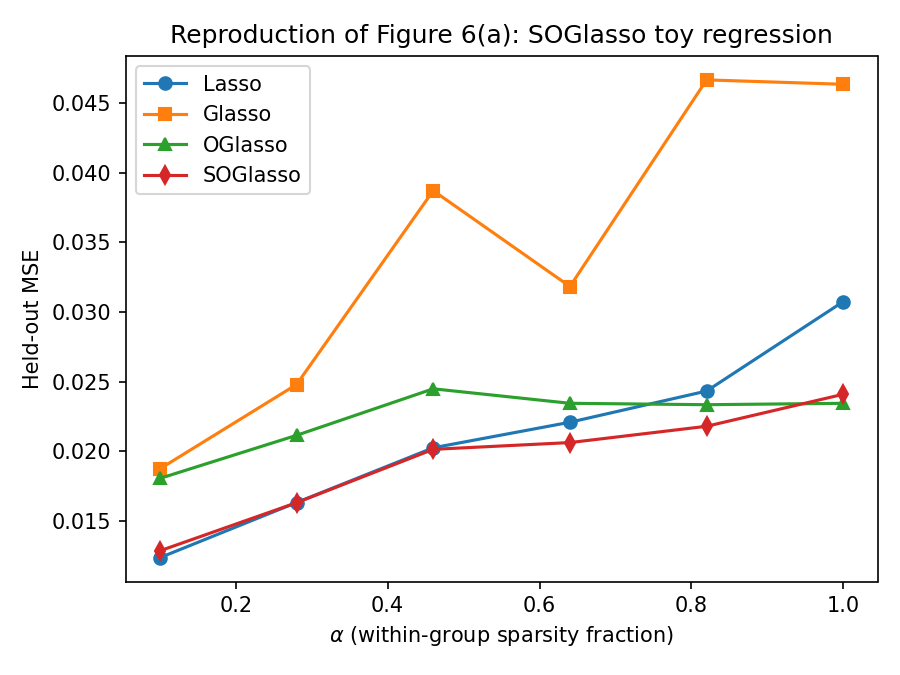

In [2]:
save_and_plot(results)

from IPython.display import Image
Image("../tutorials/figure6a_reproduction.png")

## Reading the result

- **SOGlasso** (red) tracks the best-performing baseline at every value of
  alpha -- matching Lasso when the signal is very sparse within groups, and
  pulling ahead as groups become denser, since it is the only estimator
  that models both levels of structure simultaneously.
- **Glasso** (orange) degrades as it is forced to select entire groups even
  when most of a group's coefficients are irrelevant.
- **OGlasso** (green) similarly cannot exploit within-group sparsity.
- **Lasso** (blue) ignores group structure entirely and is a strong
  baseline only in the very-sparse regime.

This matches the mechanism described in the paper: SOGlasso's penalty
`h(x) = inf sum_G (||w_G||_2 + mu||w_G||_1)` is a tight convex relaxation
of exactly this joint (k, l)-group-sparse structure (Lemma 9).